<a href="https://colab.research.google.com/github/ThanhTruc297PRJ/TH_DLN/blob/main/Buoi5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RNN**

Cài đặt RNN

In [2]:
# 1. Đọc và xử lý dữ liệu dạng bảng (ví dụ: file CSV)
from pandas import read_csv

# 2. Xử lý các phép toán số học, mảng nhiều chiều và ma trận
import numpy as np

# 3. Khởi tạo mô hình mạng nơ-ron tuần tự (xếp chồng các lớp lên nhau)
from keras.models import Sequential

# 4. Dense: Lớp nơ-ron kết nối đầy đủ; SimpleRNN: Lớp mạng nơ-ron tuần tuần hoàn cơ bản
from keras.layers import Dense, SimpleRNN

# 5. Chuẩn hóa dữ liệu về khoảng [0, 1] để mô hình học hiệu quả hơn
from sklearn.preprocessing import MinMaxScaler

# 6. Hàm tính toán sai số bình phương trung bình (MSE) để đánh giá mô hình
from sklearn.metrics import mean_squared_error

# 7. Thư viện toán học cơ bản của Python (dùng cho các hàm như căn bậc hai sqrt)
import math

# 8. Thư viện dùng để vẽ đồ thị và trực quan hóa dữ liệu
import matplotlib.pyplot as plt

In [3]:
# Tạo hàm định nghĩa mô hình RNN
def create_RNN(hidden_units, dense_units, input_shape, activation):
    # Khởi tạo một mô hình dạng chuỗi (Sequential) để xếp chồng các lớp nơ-ron
    model = Sequential()

    # Thêm lớp SimpleRNN (Mạng nơ-ron tuần hoàn cơ bản) vào mô hình
    # activation[0] lấy phần tử đầu tiên trong danh sách ['linear', 'linear'] là 'linear'
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))

    # Thêm lớp Dense (Kết nối đầy đủ) đóng vai trò là lớp đầu ra (Output layer)
    # activation[1] lấy phần tử thứ hai trong danh sách là 'linear'
    model.add(Dense(dense_units, activation=activation[1]))

    # Biên dịch mô hình: cấu hình bộ tối ưu hóa là 'adam' và hàm mất mát là sai số bình phương trung bình (MSE)
    model.compile(optimizer='adam', loss='mean_square_error')

    # Trả về đối tượng mô hình sau khi đã xây dựng xong
    return model

# Gọi hàm để khởi tạo mô hình cụ thể với các tham số:
# hidden_units = 2
# dense_units = 1
# input_shape = (3, 1)
# activation = ['linear', 'linear']
demo_RNN = create_RNN(2, 1, (3, 1), ['linear', 'linear'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Lấy danh sách tất cả các trọng số được khởi tạo ngẫu nhiên của mô hình demo_RNN
# get_weights() trả về một list chứa các mảng numpy theo thứ tự các lớp từ dưới lên trên

wx = demo_RNN.get_weights()[0]
wh = demo_RNN.get_weights()[1]
bh = demo_RNN.get_weights()[2]

wy = demo_RNN.get_weights()[3]
by = demo_RNN.get_weights()[4]

# In các giá trị trọng số ra màn hình để kiểm tra
print('wx=', wx)
print('wh=', wh)
print('bh=', bh)
print('wy=', wy)
print('by=', by)

In [7]:
#Tính vector hidden cho tầng recurrent
import numpy as np

# 1. Định nghĩa lại các ma trận trọng số lấy từ mô hình RNN (để Colab nhận diện biến)
wx = demo_RNN.get_weights()[0]
wh = demo_RNN.get_weights()[1]
bh = demo_RNN.get_weights()[2]
wy = demo_RNN.get_weights()[3]
by = demo_RNN.get_weights()[4]

# 2. Khởi tạo và reshape dữ liệu đầu vào x
x = np.array([1, 2, 3])
x_input = np.reshape(x, (1, 3, 1))

# 3. Gọi mô hình dự đoán để đối chiếu kết quả
y_predict_model = demo_RNN.predict(x_input)

# 4. Tiến hành tính toán bằng tay có bọc hàm np.tanh
m = 2
h0 = np.zeros(m)

h1 = np.tanh(np.dot(x[0], wx) + bh + h0)
h2 = np.tanh(np.dot(x[1], wx) + np.dot(h1, wh) + bh)
h3 = np.tanh(np.dot(x[2], wx) + np.dot(h2, wh) + bh)

o3 = np.dot(h3, wy) + by

# 5. In kết quả đối chiếu
print('h1:', h1)
print('h2:', h2)
print('h3:', h3)
print('Prediction of model:', y_predict_model)
print('Prediction from computation:', o3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
h1: [[0.61187412 0.47034319]]
h2: [[0.58341207 0.69976951]]
h3: [[0.86286195 0.82061887]]
Prediction of model: [[-0.9959339]]
Prediction from computation: [[-0.67124101]]


Áp dụng Rnn cho thực tế
Phần này hướng dẫn áp dụng RNN cho bài toán dự báo chuỗi thời gian cho công ty bán mỹ phẩm
dưỡng da. Bộ dữ liệu tên là Sunspots có thể tải tại địa chỉ sau
https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv

In [10]:
#Đọc dữ liệu
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def get_train_test(url, split_percent=0.8):
    df = pd.read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()

    n = len(data)

    split = int(n * split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

In [11]:
#chuẩn bị dữ liệu
def get_XY(dat, time_steps):
    #indices target arrays
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]

    #prepare X
    row_x = len(Y)
    X = dat[range(time_steps * row_x)]
    X = np.reshape(X, (row_x, time_steps, 1))
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

In [13]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    # Sửa cảnh báo input_shape bằng cách dùng Input layer hoặc truyền đúng chuẩn Keras 3
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(dense_units, activation=activation[1]))

    # SỬA LỖI TẠI ĐÂY: 'mean_squared_error' thay vì 'mean_square_error'
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
    return model

In [14]:
model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps, 1), activation=['tanh', 'tanh'])
model_fit = model.fit(trainX, trainY, epochs=20, verbose=1)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0428 - loss: 0.0718
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0428 - loss: 0.0656 
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0428 - loss: 0.0604 
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0428 - loss: 0.0564 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0428 - loss: 0.0534 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0428 - loss: 0.0513 
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0428 - loss: 0.0497 
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0428 - loss: 0.0480     
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0428 - loss: 0.0465 
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0428 - loss: 0.0453 
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0428 - loss: 0.0440
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0428 - loss: 0.042

In [15]:
#Hàm tính kết quả model
def print_error(trainY, testY, train_predict, test_predict):
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)
# Mean square error
print_error(trainY, testY, train_predict, test_predict)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Train RMSE: 0.185 RMSE
Test RMSE: 0.305 RMSE


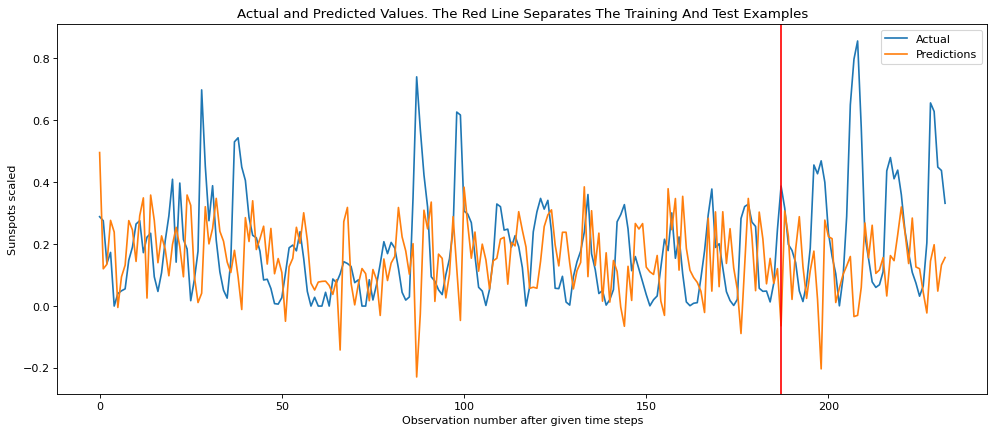

In [16]:
# Plot the result(ĐG)
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()
plot_result(trainY, testY, train_predict, test_predict)